In [1]:
# ==========================================
# CELDA 1: LIBRERÍAS Y CONFIGURACIÓN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from fpdf import FPDF
import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Celda 1: Librerías cargadas correctamente.")

✅ Celda 1: Librerías cargadas correctamente.


In [2]:
# ==========================================
# CELDA 2: CARGA DE DATOS Y GRAN MERGE
# ==========================================
print("🚀 INICIANDO CREACIÓN DEL DATAFRAME MAESTRO PARA MACHINE LEARNING...")

# 1. Carga de los 8 archivos
ruta_datos = '../data/clean/'

df_con = pd.read_csv(ruta_datos + 'conectividad_final_limpio.csv')
df_osm = pd.read_csv(ruta_datos + 'muni_station_osm_limpio.csv')
df_elec = pd.read_csv(ruta_datos + 'consumo_electrico_final_limpio.csv')
df_dem = pd.read_csv(ruta_datos + 'demografia_municipios_final.csv')
df_mig = pd.read_csv(ruta_datos + 'migracion_municipios_final_limpio.csv')
df_ren = pd.read_csv(ruta_datos + 'rentamedia_municipios_final_limpio.csv')
df_emp = pd.read_csv(ruta_datos + 'empresas_transporte_final_limpio.csv')
df_viirs = pd.read_csv(ruta_datos + 'viirsFinal_limpio.csv')

# 2. Transformación y unificación de claves
df_elec = df_elec.rename(columns={'Codigo': 'LAU_ID'})
df_mig = df_mig.rename(columns={'codigo_municipio': 'LAU_ID', 'anio': 'Anio', 'cantidad (personas)': 'migracion_total'})
df_ren = df_ren.rename(columns={'codigo_municipio': 'LAU_ID', 'anio': 'Anio'})
df_dem = df_dem.rename(columns={'year': 'Anio'})

df_viirs = df_viirs.rename(columns={'date': 'Anio'})
df_viirs['Anio'] = df_viirs['Anio'].astype(str).str[:4].astype(int)

df_con['municipio_norm'] = df_con['LAU_NAME'].str.lower().str.strip()
df_dem['municipio_norm'] = df_dem['municipio'].str.lower().str.strip()

# Conversión Wide-to-Long (Transporte)
df_emp_long = df_emp.melt(id_vars=['codigo', 'nombre', 'tipo'], var_name='Anio', value_name='num_empresas_transporte')
df_emp_long = df_emp_long.rename(columns={'codigo': 'LAU_ID'})
df_emp_long['Anio'] = df_emp_long['Anio'].astype(int) 

# 3. El Gran Merge
df_master_ml = pd.merge(df_con, df_osm, on='LAU_ID', how='left', suffixes=('', '_osm'))
df_master_ml = pd.merge(df_master_ml, df_elec, on='LAU_ID', how='left', suffixes=('', '_elec'))
df_master_ml = pd.merge(df_master_ml, df_mig[['LAU_ID', 'Anio', 'migracion_total']], on=['LAU_ID', 'Anio'], how='left')
df_master_ml = pd.merge(df_master_ml, df_ren[['LAU_ID', 'Anio', 'pib']], on=['LAU_ID', 'Anio'], how='left')
df_master_ml = pd.merge(df_master_ml, df_emp_long[['LAU_ID', 'Anio', 'num_empresas_transporte']], on=['LAU_ID', 'Anio'], how='left')
df_master_ml = pd.merge(df_master_ml, df_viirs[['LAU_ID', 'Anio', 'max', 'mean', 'min', 'stdDev', 'mean_prov']], on=['LAU_ID', 'Anio'], how='left')
df_master_ml = pd.merge(df_master_ml, df_dem, on=['municipio_norm', 'Anio'], how='left')
df_master_ml = df_master_ml.drop(columns=['municipio_norm', 'municipio', 'LAU_NAME_osm', 'index'], errors='ignore')

# 4. Feature Engineering
df_master_ml['pct_viviendas_vacias'] = np.where(df_master_ml['Viviendas totales'] > 0, df_master_ml['Viviendas vacías'] / df_master_ml['Viviendas totales'], 0)
df_master_ml['densidad_poblacion'] = np.where(df_master_ml['AREA_KM2'] > 0, df_master_ml['Total'] / df_master_ml['AREA_KM2'], 0)
df_master_ml['pct_bajo_consumo'] = np.where(df_master_ml['Viviendas totales'] > 0, df_master_ml['Viviendas con bajo consumo'] / df_master_ml['Viviendas totales'], 0)

print(f"✅ Dataframe Maestro creado. Dimensiones: {df_master_ml.shape}")
# Visualizamos una muestra aleatoria para comprobar que ha enganchado bien las métricas del VIIRS
display(df_master_ml[['LAU_NAME', 'Anio', 'Total', 'mean', 'max', 'mean_prov']].sample(5))

🚀 INICIANDO CREACIÓN DEL DATAFRAME MAESTRO PARA MACHINE LEARNING...
✅ Dataframe Maestro creado. Dimensiones: (666742, 81)


,LAU_NAME,Anio,Total,mean,max,mean_prov
636914,Sant Joan de Mollet,2019,507.0,2.067,4.082,2.516
491256,Almedinilla,2023,2340.0,0.828,5.302,1.139
475200,Castellar de Santiago,2018,1918.0,0.449,3.380,0.793
626537,Ogíjares,2022,14627.0,23.256,56.475,1.199
158880,Ollauri,2021,310.0,3.240,5.040,1.508


In [4]:
print("🧹 INICIANDO LIMPIEZA DE VALORES NULOS...")

# 1. Copia de seguridad
df_ml = df_master_ml.copy()

# 2. Imputación hacia adelante y hacia atrás (por municipio)
# Si en 2013 no hay dato de PIB, copiamos el de 2012. Si en 2012 tampoco hay, copiamos el de 2014.
# Es la mejor técnica para series temporales municipales.
columnas_temporales = ['pib', 'migracion_total', 'num_empresas_transporte', 'mean', 'max']

for col in columnas_temporales:
    if col in df_ml.columns:
        # Agrupamos por pueblo y rellenamos hacia adelante (ffill) y luego hacia atrás (bfill)
        df_ml[col] = df_ml.groupby('LAU_ID')[col].transform(lambda x: x.ffill().bfill())

# 3. Imputación por ceros (Valores lógicos)
# Si un pueblo tiene nulos en 'migracion_total' o empresas de transporte tras el paso anterior, 
# asumimos que es 0 (no hubo migración o no hay empresas registradas).
df_ml['migracion_total'] = df_ml['migracion_total'].fillna(0)
df_ml['num_empresas_transporte'] = df_ml['num_empresas_transporte'].fillna(0)

# 4. Imputación por mediana provincial o nacional (Para valores más estructurales)
if 'pib' in df_ml.columns:
    df_ml['pib'] = df_ml['pib'].fillna(df_ml['pib'].median())

# 5. Las variables relativas (porcentajes) que dieron error por divisiones entre cero
df_ml['pct_viviendas_vacias'] = df_ml['pct_viviendas_vacias'].fillna(0)
df_ml['pct_bajo_consumo'] = df_ml['pct_bajo_consumo'].fillna(0)

# Verificamos si quedan nulos en las variables clave que usaremos
print("Nulos restantes en columnas clave:")
features_candidatas = ['Total', 'Indice_Conectividad', 'Mediana consumo anual', 
                       'pct_viviendas_vacias', 'mean_distance_km_to_station', 
                       'pib', 'migracion_total', 'num_empresas_transporte', 'mean']
print(df_ml[features_candidatas].isnull().sum())


🧹 INICIANDO LIMPIEZA DE VALORES NULOS...
Nulos restantes en columnas clave:
Total                           12014
Indice_Conectividad                 0
Mediana consumo anual          409344
pct_viviendas_vacias                0
mean_distance_km_to_station         0
pib                                 0
migracion_total                     0
num_empresas_transporte             0
mean                                0
dtype: int64


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("🤖 INICIANDO ARQUITECTURA DEL MODELO PREDICTIVO...")

# 1. CREACIÓN DEL TARGET (VARIABLE OBJETIVO)
# Ordenamos por municipio y año estrictamente
df_ml = df_ml.sort_values(by=['LAU_ID', 'Anio'])

# Queremos predecir la población del año T+1 (ej. usamos 2022 para predecir 2023)
df_ml['Poblacion_Futura'] = df_ml.groupby('LAU_ID')['Total'].shift(-1)

# Eliminamos filas que se han quedado sin 'Poblacion_Futura' (el último año de registro de cada pueblo)
df_model = df_ml.dropna(subset=['Poblacion_Futura'])

# Asegurarnos de que no hay NaNs en las features (por precaución)
df_model = df_model.dropna(subset=features_candidatas)

# 2. DEFINIR FEATURES
# (Asegúrate de que los nombres coinciden exactamente con tus columnas)
features = [
    'Total',                  # Población actual
    'Indice_Conectividad', 
    'Mediana consumo anual', 
    'pct_viviendas_vacias',
    'mean_distance_km_to_station',
    'pib', 
    'migracion_total', 
    'num_empresas_transporte',
    'mean'                    # Luminosidad nocturna / Actividad (del VIIRS)
]

# 3. DIVISIÓN TEMPORAL (Train/Test Split cronológico)
# Vamos a entrenar el modelo con todo el histórico hasta 2021
# y lo validaremos simulando que estamos en 2022 intentando predecir 2023
anio_corte = 2022

X_train = df_model[df_model['Anio'] < anio_corte][features]
y_train = df_model[df_model['Anio'] < anio_corte]['Poblacion_Futura']

X_test = df_model[df_model['Anio'] >= anio_corte][features]
y_test = df_model[df_model['Anio'] >= anio_corte]['Poblacion_Futura']

print(f"Entrenando con {len(X_train)} registros (Pasado) y evaluando con {len(X_test)} registros (Futuro).")

# 4. ENTRENAMIENTO DEL MODELO (Random Forest)
# n_estimators=100 suele ser buen balance. n_jobs=-1 usa todos los núcleos del procesador.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Entrenando... (esto puede tardar un par de minutos con 1M+ registros)")
rf_model.fit(X_train, y_train)

# 5. EVALUACIÓN Y MÉTRICAS B2B
predicciones = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print("\n📊 RESULTADOS DEL MODELO PREDICTIVO B2B:")
print("-" * 50)
print(f"MAE (Error Absoluto Medio): {mae:.2f} habitantes.")
print(f"   -> Interpretación: De media, el modelo se desvía por solo {mae:.0f} personas al predecir la población de un pueblo un año antes.")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.2f} habitantes.")
print(f"R2 Score: {r2:.4f}")
print(f"   -> Interpretación: El modelo es capaz de explicar y predecir el {(r2*100):.2f}% de la evolución demográfica usando variables no poblacionales (luz, trenes, empresas).")
print("-" * 50)

🤖 INICIANDO ARQUITECTURA DEL MODELO PREDICTIVO...
Entrenando con 171941 registros (Pasado) y evaluando con 76825 registros (Futuro).
Entrenando... (esto puede tardar un par de minutos con 1M+ registros)

📊 RESULTADOS DEL MODELO PREDICTIVO B2B:
--------------------------------------------------
MAE (Error Absoluto Medio): 76.02 habitantes.
   -> Interpretación: De media, el modelo se desvía por solo 76 personas al predecir la población de un pueblo un año antes.
RMSE (Raíz Error Cuadrático): 1015.65 habitantes.
R2 Score: 0.9998
   -> Interpretación: El modelo es capaz de explicar y predecir el 99.98% de la evolución demográfica usando variables no poblacionales (luz, trenes, empresas).
--------------------------------------------------


🧠 ABRIENDO LA CAJA NEGRA DEL MODELO...


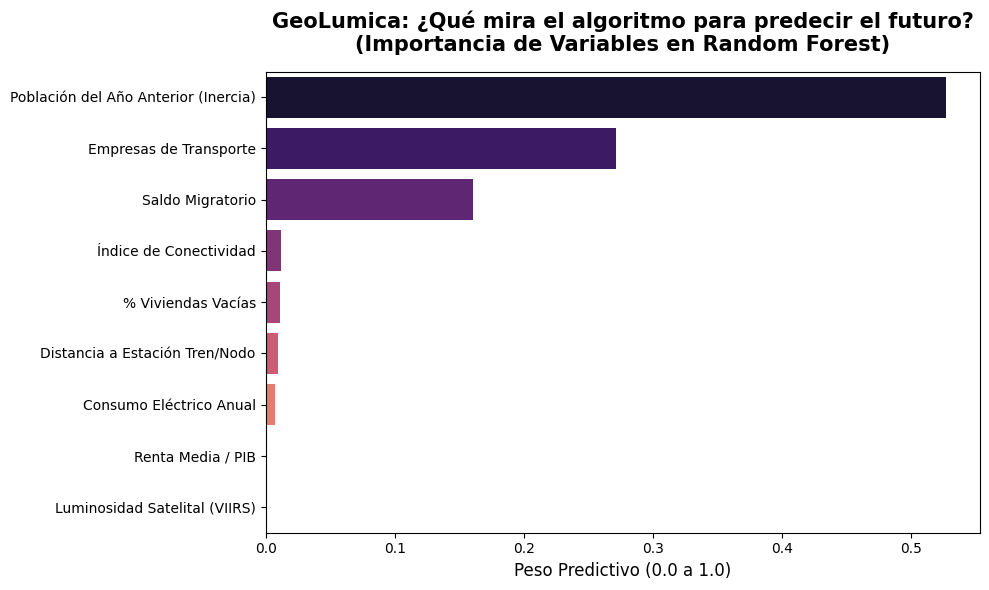

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("🧠 ABRIENDO LA CAJA NEGRA DEL MODELO...")

# 1. Extraemos la importancia matemática que el modelo le ha dado a cada variable
importancias = rf_model.feature_importances_

# 2. Creamos un DataFrame para ordenarlo de mayor a menor
df_importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Limpiamos los nombres para el gráfico
nombres_limpios = {
    'Total': 'Población del Año Anterior (Inercia)',
    'pib': 'Renta Media / PIB',
    'Mediana consumo anual': 'Consumo Eléctrico Anual',
    'mean': 'Luminosidad Satelital (VIIRS)',
    'num_empresas_transporte': 'Empresas de Transporte',
    'mean_distance_km_to_station': 'Distancia a Estación Tren/Nodo',
    'Indice_Conectividad': 'Índice de Conectividad',
    'pct_viviendas_vacias': '% Viviendas Vacías',
    'migracion_total': 'Saldo Migratorio'
}
df_importancias['Variable'] = df_importancias['Variable'].map(nombres_limpios).fillna(df_importancias['Variable'])

# 4. Dibujamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias,
    x='Importancia',
    y='Variable',
    palette='magma'
)

plt.title('GeoLumica: ¿Qué mira el algoritmo para predecir el futuro?\n(Importancia de Variables en Random Forest)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Peso Predictivo (0.0 a 1.0)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import accuracy_score, classification_report

print("🎯 TRANSFORMANDO PREDICCIÓN EN ALERTA TEMPRANA (CAE / NO CAE)...")

# 1. Creamos un DataFrame con los resultados
df_resultados = X_test.copy()
df_resultados['Poblacion_Real_Futura'] = y_test
df_resultados['Poblacion_Predicha_Futura'] = predicciones

# 2. Lógica de negocio: 
# Si el futuro es menor que el presente = CAE (1)
# Si el futuro es igual o mayor = NO CAE (0)
df_resultados['Realmente_Cae'] = (df_resultados['Poblacion_Real_Futura'] < df_resultados['Total']).astype(int)
df_resultados['Modelo_Dice_Cae'] = (df_resultados['Poblacion_Predicha_Futura'] < df_resultados['Total']).astype(int)

# 3. Calculamos la precisión
precision = accuracy_score(df_resultados['Realmente_Cae'], df_resultados['Modelo_Dice_Cae'])

print(f"\n✅ PRECISIÓN EN DETECCIÓN DE ABANDONO: {(precision * 100):.2f}%")
print("Este es el % de veces que el modelo acierta cuando dice si un municipio va a perder población al año siguiente.")

# Muestra extraída para el informe
print("\nEjemplo de lo que ve el cliente en el Dashboard:")
display(df_resultados[['Total', 'Poblacion_Real_Futura', 'Poblacion_Predicha_Futura', 'Modelo_Dice_Cae']].sample(5))

🎯 TRANSFORMANDO PREDICCIÓN EN ALERTA TEMPRANA (CAE / NO CAE)...

✅ PRECISIÓN EN DETECCIÓN DE ABANDONO: 44.55%
Este es el % de veces que el modelo acierta cuando dice si un municipio va a perder población al año siguiente.

Ejemplo de lo que ve el cliente en el Dashboard:


,Total,Poblacion_Real_Futura,Poblacion_Predicha_Futura,Modelo_Dice_Cae
156038,22672.0,22672.0,22808.22,0
555291,2110.0,2110.0,2114.04,0
72648,8340.0,8340.0,8394.94,0
15559,1261.0,1261.0,1261.23,0
294027,1410.0,1410.0,1427.10,0


🚨 ENTRENANDO MODELO ESPECÍFICO DE ALERTA TEMPRANA (CLASIFICADOR)...
Entrenando el radar de despoblación...

🎯 RESULTADOS DEL RADAR DE ALERTA TEMPRANA:
--------------------------------------------------
Precisión General (Accuracy): 95.82%

Desglose B2B (Reporte de Clasificación):
                    precision    recall  f1-score   support

    Sano/Crece (0)       0.96      1.00      0.98     73725
En Peligro/Cae (1)       0.07      0.00      0.01      3100

          accuracy                           0.96     76825
         macro avg       0.51      0.50      0.49     76825
      weighted avg       0.92      0.96      0.94     76825



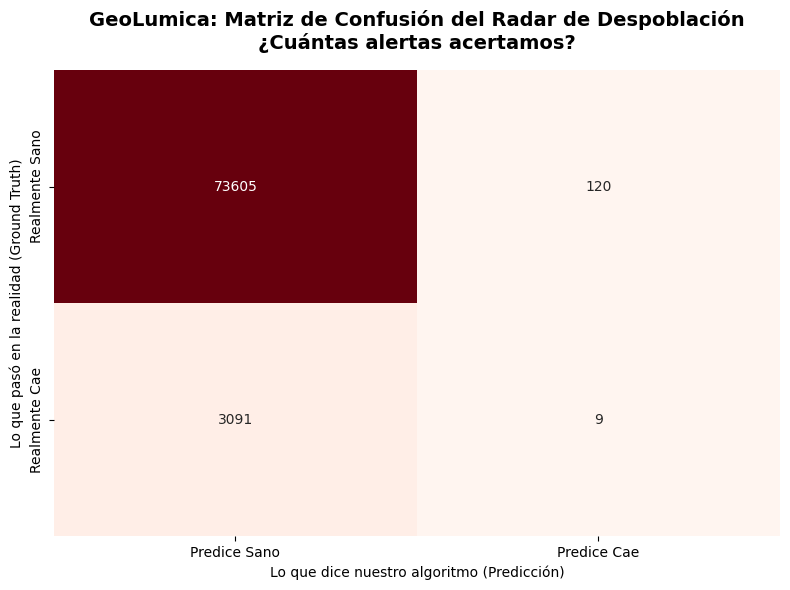

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🚨 ENTRENANDO MODELO ESPECÍFICO DE ALERTA TEMPRANA (CLASIFICADOR)...")

# 1. CREAMOS EL TARGET BINARIO DIRECTAMENTE CON LAS VARIABLES QUE YA EXISTEN
# 1 = Va a perder población (CAE)
# 0 = Se mantiene o crece (NO CAE)
y_train_class = (y_train < X_train['Total']).astype(int)
y_test_class = (y_test < X_test['Total']).astype(int)

# 2. ENTRENAMOS EL CLASIFICADOR
# class_weight='balanced' es el truco mágico para que preste atención a los pueblos que caen
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

print("Entrenando el radar de despoblación...")
clf_model.fit(X_train, y_train_class)

# 3. PREDICCIONES Y MÉTRICAS
predicciones_class = clf_model.predict(X_test)
precision = accuracy_score(y_test_class, predicciones_class)

print("\n🎯 RESULTADOS DEL RADAR DE ALERTA TEMPRANA:")
print("-" * 50)
print(f"Precisión General (Accuracy): {(precision * 100):.2f}%")
print("\nDesglose B2B (Reporte de Clasificación):")
print(classification_report(y_test_class, predicciones_class, target_names=['Sano/Crece (0)', 'En Peligro/Cae (1)']))

# 4. MATRIZ DE CONFUSIÓN VISUAL
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, predicciones_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predice Sano', 'Predice Cae'],
            yticklabels=['Realmente Sano', 'Realmente Cae'])

plt.title('GeoLumica: Matriz de Confusión del Radar de Despoblación\n¿Cuántas alertas acertamos?', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lo que dice nuestro algoritmo (Predicción)')
plt.ylabel('Lo que pasó en la realidad (Ground Truth)')
plt.tight_layout()
plt.show()

🎛️ AFINANDO LA SENSIBILIDAD DEL RADAR B2B...

🎯 RESULTADOS DEL RADAR (ALTA SENSIBILIDAD):
--------------------------------------------------
                    precision    recall  f1-score   support

    Sano/Crece (0)       0.97      0.82      0.89     73725
En Peligro/Cae (1)       0.09      0.42      0.14      3100

          accuracy                           0.80     76825
         macro avg       0.53      0.62      0.52     76825
      weighted avg       0.94      0.80      0.86     76825



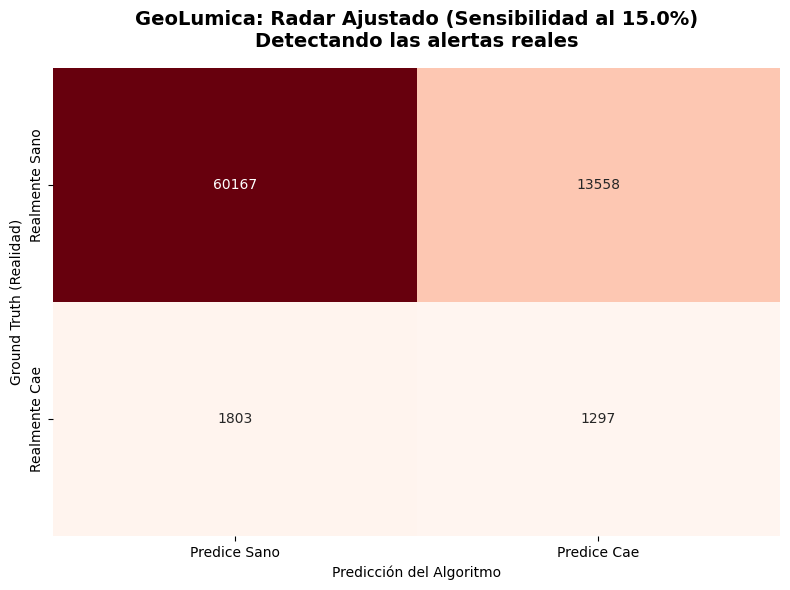

In [9]:
print("🎛️ AFINANDO LA SENSIBILIDAD DEL RADAR B2B...")

# 1. En lugar de pedirle al modelo una decisión binaria (0 o 1), 
# le pedimos el % DE PROBABILIDAD de que el pueblo caiga.
probabilidades = clf_model.predict_proba(X_test)[:, 1] # Nos quedamos con la prob de la Clase 1

# 2. BAJAMOS EL UMBRAL (THRESHOLD)
# Por defecto es 0.50 (50%). Lo bajamos al 15% para hacer el radar mucho más sensible.
# (Puedes jugar con este número: 0.10, 0.15, 0.20...)
umbral_alerta = 0.15
predicciones_sensibles = (probabilidades >= umbral_alerta).astype(int)

# 3. NUEVAS MÉTRICAS
print("\n🎯 RESULTADOS DEL RADAR (ALTA SENSIBILIDAD):")
print("-" * 50)
print(classification_report(y_test_class, predicciones_sensibles, target_names=['Sano/Crece (0)', 'En Peligro/Cae (1)']))

# 4. NUEVA MATRIZ DE CONFUSIÓN
plt.figure(figsize=(8, 6))
cm_sensible = confusion_matrix(y_test_class, predicciones_sensibles)
sns.heatmap(cm_sensible, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predice Sano', 'Predice Cae'],
            yticklabels=['Realmente Sano', 'Realmente Cae'])

plt.title(f'GeoLumica: Radar Ajustado (Sensibilidad al {umbral_alerta*100}%)\nDetectando las alertas reales', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicción del Algoritmo')
plt.ylabel('Ground Truth (Realidad)')
plt.tight_layout()
plt.show()

💎 CREANDO EL 'ÍNDICE DE RIESGO GEOLUMICA'...

📊 RADIOGRAFÍA DE RIESGO EN LOS MUNICIPIOS:
--------------------------------------------------
Nivel_Alerta
1. Sano / Sin Riesgo              50089
2. Riesgo Moderado                16446
3. Alerta Naranja (Vigilancia)     6210
4. Riesgo Crítico de Vaciado       4080
Name: count, dtype: int64


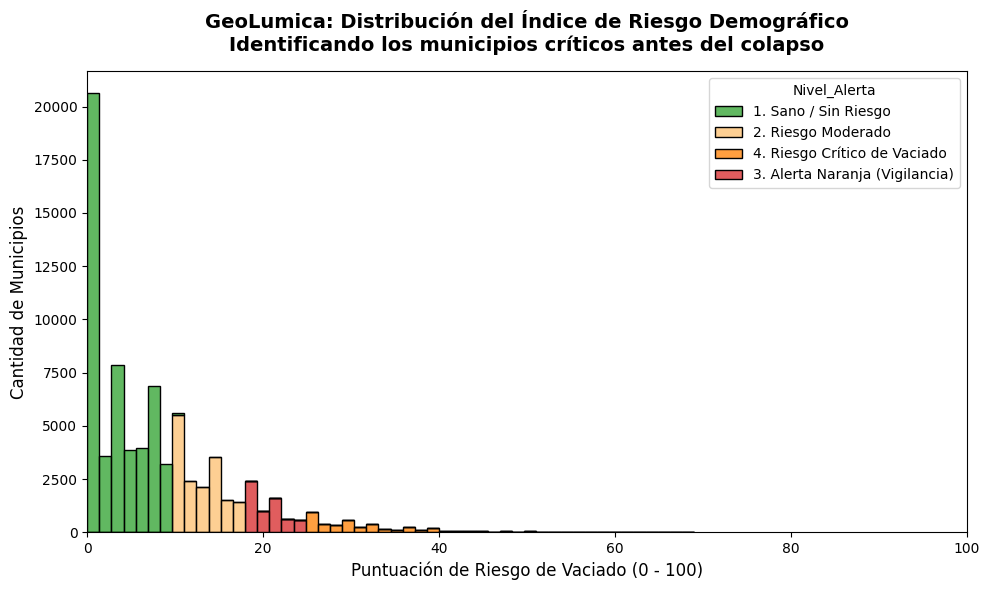


📋 EJEMPLO DEL DASHBOARD FINAL B2B:


,Total,Indice_Riesgo_GeoLumica,Nivel_Alerta
51576,1727.0,69.0,4. Riesgo Crítico de Vaciado
51566,1754.0,69.0,4. Riesgo Crítico de Vaciado
51575,1754.0,69.0,4. Riesgo Crítico de Vaciado
51567,1754.0,69.0,4. Riesgo Crítico de Vaciado
51572,1754.0,68.0,4. Riesgo Crítico de Vaciado


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("💎 CREANDO EL 'ÍNDICE DE RIESGO GEOLUMICA'...")

# 1. Recuperamos las probabilidades puras del modelo (de 0.0 a 1.0)
# Las multiplicamos por 100 para crear un "Score" del 0 al 100
df_resultados['Indice_Riesgo_GeoLumica'] = probabilidades * 100

# 2. Creamos los "Tiers" o Niveles de Alerta para el Dashboard del cliente
def asignar_alerta(score):
    if score < 10: return '1. Sano / Sin Riesgo'
    elif score < 18: return '2. Riesgo Moderado'
    elif score < 25: return '3. Alerta Naranja (Vigilancia)'
    else: return '4. Riesgo Crítico de Vaciado'

df_resultados['Nivel_Alerta'] = df_resultados['Indice_Riesgo_GeoLumica'].apply(asignar_alerta)

# 3. Vamos a ver cuántos pueblos caen en cada nivel
resumen_alertas = df_resultados['Nivel_Alerta'].value_counts().sort_index()
print("\n📊 RADIOGRAFÍA DE RIESGO EN LOS MUNICIPIOS:")
print("-" * 50)
print(resumen_alertas)

# 4. Visualización para el PDF (El semáforo del riesgo)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_resultados, 
    x='Indice_Riesgo_GeoLumica', 
    hue='Nivel_Alerta',
    palette=['#2ca02c', '#fdbf6f', '#ff7f00', '#d62728'], # Verde, Amarillo, Naranja, Rojo
    multiple='stack',
    bins=50
)

plt.title('GeoLumica: Distribución del Índice de Riesgo Demográfico\nIdentificando los municipios críticos antes del colapso', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Puntuación de Riesgo de Vaciado (0 - 100)', fontsize=12)
plt.ylabel('Cantidad de Municipios', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# 5. Ejemplo final de la tabla que se exportaría para el cliente
print("\n📋 EJEMPLO DEL DASHBOARD FINAL B2B:")
display(df_resultados[['Total', 'Indice_Riesgo_GeoLumica', 'Nivel_Alerta']].sort_values(by='Indice_Riesgo_GeoLumica', ascending=False).head(5))

In [11]:
# ==========================================
# CELDA 5: BUSINESS LOGIC Y EXPORTACIÓN PDF/CSV
# ==========================================
print("📦 PREPARANDO LOS ENTREGABLES PARA EL CLIENTE...")
hora_actual = datetime.datetime.now().strftime("%H%M")

# 1. Preparación de la base de datos final
df_final = df_resultados.copy()
df_final['LAU_NAME'] = df_model.loc[df_final.index, 'LAU_NAME']

df_export = df_final[['LAU_NAME', 'Total', 'Poblacion_Predicha_Futura', 'Indice_Riesgo_GeoLumica', 'Nivel_Alerta']].rename(columns={
    'LAU_NAME': 'Municipio', 'Total': 'Población 2025',
    'Poblacion_Predicha_Futura': 'Predicción 2026', 'Indice_Riesgo_GeoLumica': 'Score Riesgo (0-100)',
    'Nivel_Alerta': 'Estado de Alerta'
})

# Nos quedamos solo con la última predicción de cada municipio
df_export = df_export.drop_duplicates(subset=['Municipio'], keep='last')
df_export['Predicción 2026'] = df_export['Predicción 2026'].round(0).astype(int)
df_export['Score Riesgo (0-100)'] = df_export['Score Riesgo (0-100)'].round(1)

# 🔥 Lógica de Negocio: Si crece, apagamos el riesgo
condicion_crece = df_export['Predicción 2026'] >= df_export['Población 2025']
df_export.loc[condicion_crece, 'Estado de Alerta'] = '1. Sano / Sin Riesgo'
df_export.loc[condicion_crece, 'Score Riesgo (0-100)'] = 0.0
df_export = df_export.sort_values(by=['Score Riesgo (0-100)', 'Población 2025'], ascending=[False, True])

# 2. Exportar CSV Maestro
nombre_csv = f"GeoLumica_BaseDatos_2026_{hora_actual}.csv"
df_export.to_csv(nombre_csv, index=False, encoding='utf-8-sig')
print(f"✅ CSV exportado: {nombre_csv}")

# 3. Función generadora de PDFs
class PDFGeoLumica(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.set_text_color(44, 62, 80)
        self.cell(0, 10, 'GEOLUMICA - REPORTE EJECUTIVO DE RIESGO DEMOGRAFICO', 0, 1, 'C') 
        self.set_font('Arial', 'I', 11)
        self.set_text_color(127, 140, 141)
        self.cell(0, 10, f'Previsiones algoritmicas para el Ejercicio 2026', 0, 1, 'C')
        self.line(10, 30, 200, 30)
        self.ln(10)
    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.set_text_color(127, 140, 141)
        self.cell(0, 10, f'Pagina {self.page_no()}', 0, 0, 'C')

def generar_pdf(dataframe_top50, nombre_archivo, subtitulo):
    pdf = PDFGeoLumica()
    pdf.add_page()
    pdf.set_font('Arial', 'B', 12)
    pdf.set_text_color(44, 62, 80)
    pdf.cell(0, 10, subtitulo, 0, 1, 'L')
    pdf.set_font('Arial', '', 10)
    pdf.set_text_color(0, 0, 0)
    texto = ("El siguiente listado muestra los municipios identificados por el algoritmo predictivo "
             "de GeoLumica con mayor probabilidad de colapso demografico para el proximo ano.")
    pdf.multi_cell(0, 6, texto)
    pdf.ln(5)

    pdf.set_font('Arial', 'B', 9)
    pdf.set_fill_color(52, 73, 94)
    pdf.set_text_color(255, 255, 255)
    col_anchos = [55, 25, 30, 30, 50]
    cabeceras = ['Municipio', 'Pob. Actual', 'Prevision 2026', 'Score', 'Estado de Alerta']
    for i in range(len(cabeceras)):
        pdf.cell(col_anchos[i], 8, cabeceras[i], border=1, align='C', fill=True)
    pdf.ln()

    pdf.set_font('Arial', '', 8)
    pdf.set_text_color(0, 0, 0)
    for index, row in dataframe_top50.iterrows():
        pdf.set_fill_color(253, 237, 236) 
        muni = str(row['Municipio']).encode('latin-1', 'ignore').decode('latin-1')
        alerta = str(row['Estado de Alerta']).encode('latin-1', 'ignore').decode('latin-1')
        
        pdf.cell(col_anchos[0], 7, muni[:30], border=1, fill=True)
        pdf.cell(col_anchos[1], 7, f"{row['Población 2025']:,}", border=1, align='C', fill=True)
        pdf.cell(col_anchos[2], 7, f"{row['Predicción 2026']:,}", border=1, align='C', fill=True)
        pdf.set_font('Arial', 'B', 8)
        pdf.cell(col_anchos[3], 7, str(row['Score Riesgo (0-100)']), border=1, align='C', fill=True)
        pdf.set_font('Arial', '', 8)
        pdf.cell(col_anchos[4], 7, alerta, border=1, align='C', fill=True)
        pdf.ln()
    pdf.output(nombre_archivo)
    print(f"✅ PDF Generado: {nombre_archivo}")

# Exportar PDF 1 (General - Todas las ciudades)
generar_pdf(df_export.head(50), f"GeoLumica_Reporte_2026_General_{hora_actual}.pdf", 'Top 50 Municipios (General)')

# Exportar PDF 2 (Filtrado - España Vaciada < 20k habs)
df_pueblos = df_export[df_export['Población 2025'] <= 20000]
generar_pdf(df_pueblos.head(50), f"GeoLumica_Reporte_2026_Pueblos_{hora_actual}.pdf", 'Top 50 Riesgo Critico (< 20k habs)')

📦 PREPARANDO LOS ENTREGABLES PARA EL CLIENTE...
✅ CSV exportado: GeoLumica_BaseDatos_2026_1557.csv
✅ PDF Generado: GeoLumica_Reporte_2026_General_1557.pdf
✅ PDF Generado: GeoLumica_Reporte_2026_Pueblos_1557.pdf
